# Classificação Binária de Notícias em Português (Real vs Fake)

## Introdução
Este notebook apresenta uma análise de classificação binária de notícias em português usando o Fake.br-Corpus, com foco em distinguir notícias reais (`label = 0`) de notícias falsas (`label = 1`).

A proposta combina duas frentes metodológicas:
- pipeline tradicional de NLP/ML (preprocessamento, engenharia de atributos e modelagem clássica);
- pipeline baseado em Transformers para comparação de desempenho e robustez.

## Objetivos
- consolidar e validar o corpus no ambiente Google Colab;
- documentar etapas de limpeza e transformação textual com rastreabilidade;
- produzir uma base pronta para experimentos supervisionados e avaliação comparativa.

## Estrutura do Notebook
- 0. Inicialização do ambiente e montagem do Google Drive;
- 1. Configuração de dependências e utilitários de exibição;
- 2. Consolidação e engenharia do corpus;
- 3. Análise exploratória (EDA);
- 4. Pré-processamento textual e análise de impacto no tamanho dos textos.

## Observações de Reprodutibilidade
- caminho esperado do dataset: `/content/drive/MyDrive/Fake.br-Corpus/`;
- a execução deve seguir a ordem das seções para evitar variáveis incompletas no estado da sessão.

## 0. Inicialização do Ambiente

### 0.1. Montagem do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuração do Ambiente e Dependências
Nesta seção, realizamos a instalação e o carregamento de todas as dependências necessárias para a execução do pipeline de Processamento de Linguagem Natural (NLP) e manipulação de dados.

### 1.1. Instalação de Pacotes e Importação de Bibliotecas

In [44]:
# Instalação e download de modelos de NLP necessários para o processamento em português
!python -m spacy download pt_core_news_sm

import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textwrap import fill
from IPython.display import HTML, display

%matplotlib inline

# Download do dicionário de stopwords do NLTK
nltk.download('stopwords')

#
nltk.download('wordnet')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 56.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
# Configuração global de exibição textual
LARGURA_TEXTO_PADRAO = 110
MAX_COLWIDTH_DF = 140

pd.set_option('display.max_colwidth', MAX_COLWIDTH_DF)

def wrap_texto(texto, largura=LARGURA_TEXTO_PADRAO):
    if pd.isna(texto):
        return ''
    return fill(str(texto), width=largura)

# Aplica quebra de linha nas células de tabelas exibidas no notebook
display(HTML(f"""
<style>
table.dataframe td {{
  white-space: pre-wrap;
  word-break: break-word;
  max-width: {LARGURA_TEXTO_PADRAO}ch;
}}
</style>
"""))

## 2. Consolidação e Engenharia do Corpus (Fake.br-Corpus)
O bloco a seguir valida o ambiente de diretórios do Google Drive e encapsula a lógica de extração textual e síncrona dos 25 metadados oficiais do corpus linguístico.

### 2.1. Validação de Caminhos no Google Drive

In [3]:
basepath = '/content/drive/MyDrive/Fake.br-Corpus/full_texts/'

if not os.path.exists(basepath):
    print("Erro Crítico: A pasta 'full_texts' não foi encontrada no seu Drive. Verifique o caminho.")
    exit()

### 2.2. Construção Programática da Base Consolidada

In [4]:
def construir_base_dados():
    """
    Realiza a leitura iterativa do Fake.br-Corpus, mapeando de forma síncrona
    as notícias completas e suas respectivas linhas de metadados associados.
    """
    lista_registros = []

    def processar_pasta(pasta_txt, pasta_meta, label_classificacao):
        if not os.path.exists(pasta_txt):
            print(f"Erro Crítico: A pasta {pasta_txt} não foi encontrada no seu Drive.")
            return

        arquivos = sorted([f for f in os.listdir(pasta_txt) if f.endswith('.txt')])
        print(f"Total de notícias encontradas nesta pasta: {len(arquivos)}")

        # Mapeamento exato dos 25 metadados oficiais fornecidos pelo corpus estruturado
        nomes_metadados = [
            'autor', 'link_fonte', 'categoria', 'data_publicacao', 'num_tokens',
            'num_palavras_sem_pontuacao', 'num_types', 'num_links_internos',
            'num_palavras_maiusculas', 'num_verbos', 'num_verbos_subj_imperativo',
            'num_substantivos', 'num_adjetivos', 'num_adverbios', 'num_verbos_modais',
            'num_pronomes_sing_1_2', 'num_pronomes_plu_1', 'num_pronomes', 'pausabilidade',
            'num_caracteres', 'comprimento_medio_sentenca', 'comprimento_medio_palavra',
            'porcentagem_erros_ortograficos', 'emotividade', 'diversidade_lexical'
        ]

        for arquivo in arquivos:
            caminho_arquivo_txt = os.path.join(pasta_txt, arquivo)
            arquivo_sem_ext = arquivo.replace('.txt', '')
            caminho_arquivo_meta = os.path.join(pasta_meta, arquivo_sem_ext + '-meta.txt')

            # Tratamento de fallback de encoding para salvaguardar acentuações em português
            texto_noticia = ""
            for enc in ['utf-8-sig', 'latin-1']:
                try:
                    with open(caminho_arquivo_txt, 'r', encoding=enc) as f:
                        texto_noticia = f.read().strip()
                    break
                except UnicodeDecodeError:
                    continue

            metadados_extraidos = {coluna: None for coluna in nomes_metadados}

            if os.path.exists(caminho_arquivo_meta):
                conteudo_meta = ""
                for enc in ['utf-8-sig', 'latin-1']:
                    try:
                        with open(caminho_arquivo_meta, 'r', encoding=enc) as f:
                            conteudo_meta = f.read()
                        break
                    except UnicodeDecodeError:
                        continue

                if conteudo_meta:
                    linhas_meta = [linha.strip() for linha in conteudo_meta.splitlines()]
                    for i in range(min(len(linhas_meta), 25)):
                        if linhas_meta[i]:
                            coluna_atual = nomes_metadados[i]
                            metadados_extraidos[coluna_atual] = linhas_meta[i]

            registro = {
                'id_original': arquivo_sem_ext,
                'texto_completo': texto_noticia,
                'label': label_classificacao
            }
            registro.update(metadados_extraidos)
            lista_registros.append(registro)

    print(">> Carregando instâncias de notícias FALSAS...")
    processar_pasta(basepath + 'fake', basepath + 'fake-meta-information', label_classificacao=1)

    print(">> Carregando instâncias de notícias VERDADEIRAS...")
    processar_pasta(basepath + 'true', basepath + 'true-meta-information', label_classificacao=0)

    return pd.DataFrame(lista_registros)

## 3. Análise Exploratória e Qualidade de Dados (EDA)
Abaixo, carregamos o arquivo final em disco para garantir a persistência dos dados brutos e iniciamos as verificações de balanceamento de classes.

### 3.1. Carregamento do Dataset e Inspeção Inicial

In [13]:
df = pd.read_csv('/content/drive/MyDrive/Fake.br-Corpus/fake.br-full_texts.csv')
df = df[['label', 'texto_completo', 'categoria']]
print(df['label'].value_counts())
print("Dimensões do Dataset:", df.shape)

label
1    3600
0    3600
Name: count, dtype: int64
Dimensões do Dataset: (7200, 3)


### 3.2. Distribuição das Classes e Categorias

#### 3.2.1. Distribuição de Classes (Fake vs. Real)
- Gráfico de barras mostrando a proporção de notícias reais e falsas.

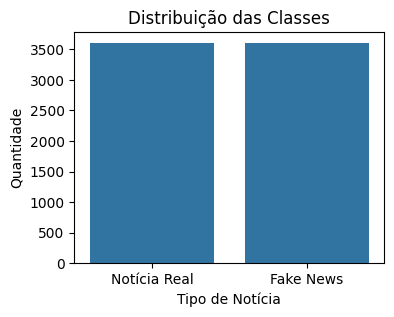

In [14]:
# Visualização gráfica da distribuição balanceada das classes
plt.figure(figsize=(4,3))
ax = sns.countplot(x=df['label'])
plt.xticks([0, 1], ['Notícia Real', 'Fake News'])
ax.set(xlabel='Tipo de Notícia', ylabel='Quantidade', title='Distribuição das Classes')
plt.show()

#### 3.2.2. Distribuição por Categoria
- Gráfico de barras mostrando a distribuição de notícias por categoria (Política, Esporte, Entretenimento, etc.).

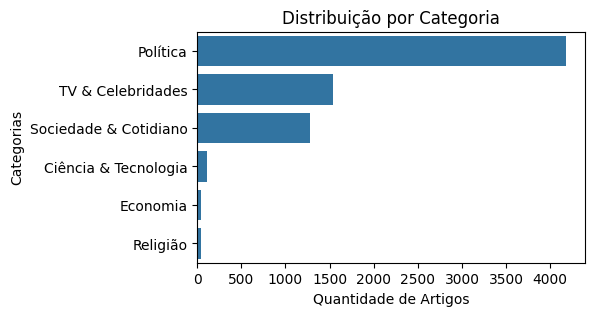

In [16]:
# Distribuição volumétrica dos documentos pelas categorias linguísticas
plt.figure(figsize=(5,3))
sns.countplot(y=df['categoria'])
plt.xlabel('Quantidade de Artigos')
plt.ylabel('Categorias')
plt.title('Distribuição por Categoria')
plt.yticks(ticks=[0, 1, 2, 3, 4, 5], labels=['Política', 'TV & Celebridades', 'Sociedade & Cotidiano', 'Ciência & Tecnologia', 'Economia', 'Religião'])
plt.show()

#### 3.2.3. Análise de Comprimento dos Textos
- Boxplot ou histograma mostrando a distribuição do número de palavras por notícia.

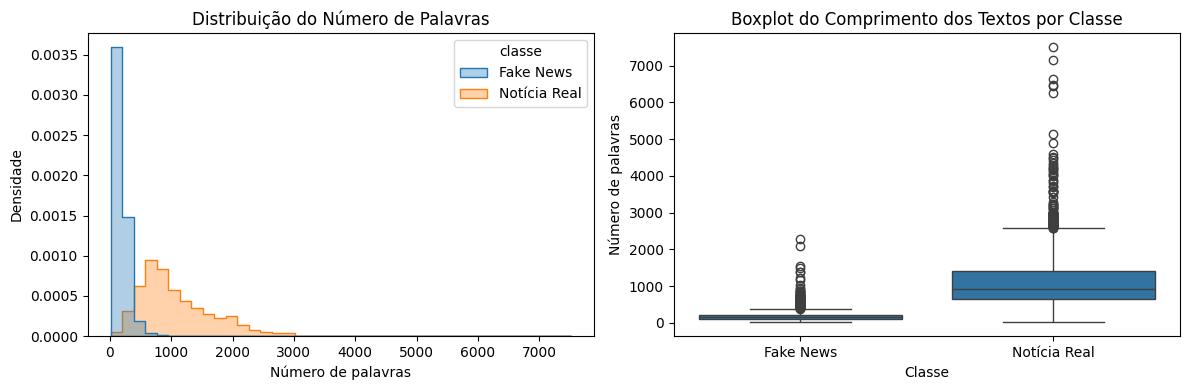

,count,mean,std,min,25%,50%,75%,max
classe,,,,,,,,
Fake News,3600.0,185.89,127.63,9.0,115.0,157.0,224.0,2288.0
Notícia Real,3600.0,1100.29,682.97,20.0,642.0,918.0,1416.0,7517.0


In [17]:
# Métrica de comprimento: número de palavras por notícia
df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

# Mapeamento para rótulos legíveis no gráfico
mapa_rotulos = {0: 'Notícia Real', 1: 'Fake News'}
df['classe'] = df['label'].map(mapa_rotulos)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma por classe
sns.histplot(
    data=df,
    x='num_palavras_texto',
    hue='classe',
    bins=40,
    element='step',
    stat='density',
    common_norm=False,
    alpha=0.35,
    ax=axes[0]
 )
axes[0].set_title('Distribuição do Número de Palavras')
axes[0].set_xlabel('Número de palavras')
axes[0].set_ylabel('Densidade')

# Boxplot por classe
sns.boxplot(data=df, x='classe', y='num_palavras_texto', ax=axes[1])
axes[1].set_title('Boxplot do Comprimento dos Textos por Classe')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Número de palavras')

plt.tight_layout()
plt.show()

# Estatísticas descritivas rápidas
display(df.groupby('classe')['num_palavras_texto'].describe().round(2))

## 4. Pipeline de Limpeza de Texto (Data Cleaning & Stopwords Fusion)
Nesta fase, removemos valores nulos residuais e criamos a união de stopwords das bibliotecas NLTK e SpaCy para o pré-processamento avançado.

### 4.1. Diagnóstico de Nulos e União de Stopwords

In [8]:
# Tem dados nulos ou em branco?
print("Valores ausentes:\n", df.isna().sum())

# All Stopwords
nlp = spacy.load('pt_core_news_sm')
stopwords_spacy = nlp.Defaults.stop_words
stopwords_nltk = stopwords.words('portuguese')
all_stopwords = list(stopwords_spacy.union(set(stopwords_nltk)))
print(f"Total unificado de Stopwords para a língua portuguesa: {len(all_stopwords)}")

Valores ausentes:
 label             0
texto_completo    0
categoria         0
dtype: int64
Total unificado de Stopwords para a língua portuguesa: 500


### 4.2. Inicialização do Lematizador

In [9]:
lemma=WordNetLemmatizer()

### 4.3. Função de Limpeza Textual e Aplicação no Dataset

In [40]:
def text_cleaning(text):

  text = '' if pd.isna(text) else str(text)

  # Convertendo texto para minúsculas
  text = text.lower()

  # Remove caracteres especiais preservando letras acentuadas e dígitos
  text = re.sub(r'[-()"#/@;:<>{}`+=~|.!?,]', ' ', text)

  # Normaliza todos os espaços em branco (incluindo tabs/quebras)
  text = re.sub(r'\s+', ' ', text).strip()

  # Removendo stopwords e aplicando lematização sem gerar espaços duplicados
  tokens_limpos = []
  for word in text.split():
    if word not in all_stopwords:
      tokens_limpos.append(lemma.lemmatize(word))

  return ' '.join(tokens_limpos)

# Execução da limpeza de texto criando a feature limpa
df['clean_text'] = df['texto_completo'].apply(text_cleaning)

# Verificação rápida de qualidade: não deve haver espaços múltiplos
multiplos_espacos = df['clean_text'].str.contains(r'\s{2,}', regex=True, na=False).sum()
print(f"Registros com múltiplos espaços em clean_text (NAO FUNCIONA AINDA): {multiplos_espacos}")

df.head()

Registros com múltiplos espaços em clean_text: 0


,label,texto_completo,categoria,num_palavras_texto,classe,clean_text
0,1,Kátia Abreu diz que vai colocar sua expulsão e...,politica,182,Fake News,kátia abreu colocar expulsão moldura reclamar ...
1,1,"Dr. Ray peita Bolsonaro, chama-o de conservad...",politica,253,Fake News,dr ray peita bolsonaro chama conservador fake...
2,1,Reinaldo Azevedo desmascarado pela Polícia Fed...,politica,273,Fake News,reinaldo azevedo desmascarado polícia federal ...
3,1,Relatório assustador do BNDES mostra dinheiro ...,politica,573,Fake News,relatório assustador bndes mostra dinheiro púb...
4,1,"Radialista americano fala sobre o PT: ""Eles ve...",politica,119,Fake News,radialista americano fala pt vendem ilusão bra...


### 4.4. Exemplo Sequencial de Pré-processamento (Antes e Depois)

In [51]:
# Seleciona um texto real do corpus para demonstração
texto_exemplo = df['texto_completo'].dropna().astype(str).iloc[0]
num_palavras_original = len(texto_exemplo.split())

print(f"Texto Original (palavras: {num_palavras_original}):\n")
print(wrap_texto(texto_exemplo))

Texto Original (palavras: 182):

Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar.    A senadora Kátia
Abreu (sem partido-TO) disse que sua expulsão do PMDB foi resultado de uma ação da cúpula atual da legenda
que, segundo ela, é oportunista.  “Amanhã eu vou botar numa moldura dourada a minha expulsão, porque das mãos
de onde veio, é um atestado de boa conduta para o meu currículo. Essas pessoas que me expulsaram não servem ao
país. Eles se servem do país em seus benefícios próprios”, disse Kátia Abreu.  Ué, mas se a expulsão é algo
tão bom para seu currículo, por que tanta choradeira, Kátia?  Sabemos o motivo. Provavelmente Kátia não tem
valor para o PT, partido que já deveria tê-la absorvido. Ao que parece o PT gostava de Kátia somente se ela
ficasse entrincheirada dentro do PMDB.  Ou seja, isso é se rebaixar demais. Resta a Kátia ficar chorando as
pitangas por todos os cantos.  Em tempo: até o momento o PT não cadastrou Kátia Abreu em suas fileir

In [52]:
# Aplica a função de limpeza ao texto de exemplo
texto_limpo_exemplo = text_cleaning(texto_exemplo).strip()
num_palavras_limpo = len(texto_limpo_exemplo.split())
compactacao_pct = 0 if num_palavras_original == 0 else ((num_palavras_original - num_palavras_limpo) / num_palavras_original) * 100

print(f"\nTexto Limpo (palavras: {num_palavras_limpo} | compactação: {compactacao_pct:.1f}%):\n")
print(wrap_texto(texto_limpo_exemplo))


Texto Limpo (palavras: 81 | compactação: 55.5%):

kátia abreu colocar expulsão moldura reclamar senadora kátia abreu partido to disse expulsão pmdb resultado
ação cúpula atual legenda oportunista “amanhã vou botar moldura dourada expulsão mãos veio atestado conduta
currículo pessoas expulsaram servem país servem país benefícios próprios” disse kátia abreu ué expulsão
currículo choradeira kátia sabemos motivo provavelmente kátia pt partido deveria tê la absorvido pt gostava
kátia ficasse entrincheirada pmdb rebaixar resta kátia ficar chorando pitanga canto pt cadastrou kátia abreu
fileiras situação patética ex ministra agricultura dilma


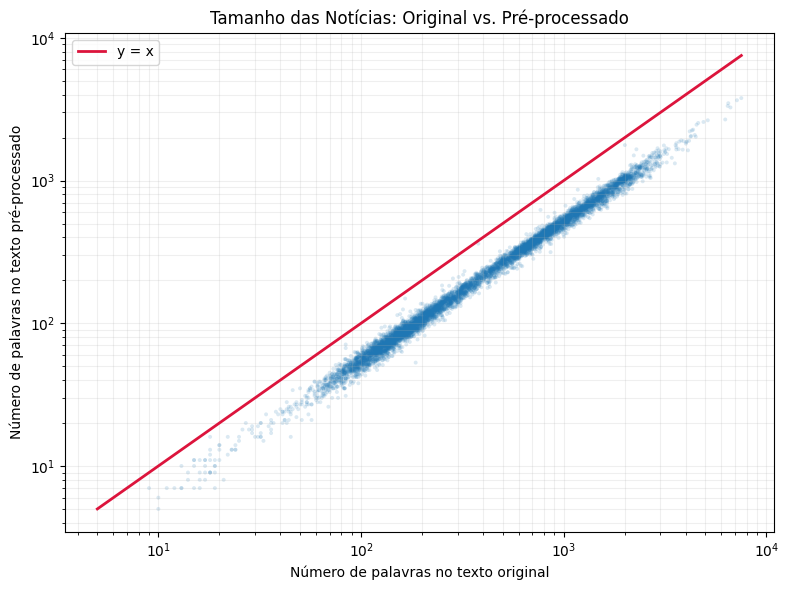

Redução média de tamanho no corpus: 47.3%


In [68]:
# Comparação de tamanho para todos os registros: original vs. pré-processado
if 'num_palavras_texto' not in df.columns:
    df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

if 'clean_text' not in df.columns:
    df['clean_text'] = df['texto_completo'].apply(text_cleaning)

df['num_palavras_limpo'] = df['clean_text'].fillna('').astype(str).str.split().str.len()

comparacao_tamanhos = df[['num_palavras_texto', 'num_palavras_limpo']].copy()
comparacao_tamanhos = comparacao_tamanhos[(comparacao_tamanhos['num_palavras_texto'] > 0) & (comparacao_tamanhos['num_palavras_limpo'] > 0)]

x = comparacao_tamanhos['num_palavras_texto']
y = comparacao_tamanhos['num_palavras_limpo']

limite_max = max(x.max(), y.max())
limite_min = min(x.min(), y.min())

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, s=8, alpha=0.16, color='#1f77b4', edgecolors='none')
ax.plot([limite_min, limite_max], [limite_min, limite_max], color='crimson', linewidth=2, label='y = x')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('Tamanho das Notícias: Original vs. Pré-processado')
ax.set_xlabel('Número de palavras no texto original')
ax.set_ylabel('Número de palavras no texto pré-processado')
ax.grid(alpha=0.2, which='both')
ax.legend()

plt.tight_layout()
plt.show()

reducao_media_pct = ((x - y) / x).mean() * 100
print(f'Redução média de tamanho no corpus: {reducao_media_pct:.1f}%')

#### 4.4.1. Diferença de Tamanho: Sentença Original vs. Pré-processada



In [38]:


# Função para visualização compacta
def resumir_texto(txt, limite=350):
    txt = txt.strip()
    return txt if len(txt) <= limite else txt[:limite] + ' ...'

comparativo_preprocessamento = pd.DataFrame({
    'Etapa': [
        '0 - Texto original',
        '1 - Após text_cleaning()'
    ],
    'Num_palavras': [
        len(texto_exemplo.split()),
        len(texto_limpo_exemplo.split())
    ],
    'Texto (resumo)': [
        resumir_texto(texto_exemplo),
        resumir_texto(texto_limpo_exemplo)
    ]
})

display(comparativo_preprocessamento)

,Etapa,Num_palavras,Texto (resumo)
0,0 - Texto original,182,Kátia Abreu diz que vai colocar sua expulsão e...
1,1 - Após text_cleaning(),81,kátia abreu colocar expulsão moldura reclamar ...


### 4.5. Comparação de Tamanho das Notícias (Antes vs. Depois)
Visualização comparativa do número de palavras por notícia antes da limpeza e após `text_cleaning`.

/tmp/ipykernel_11307/3807300746.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Corpus', y='Tamanho', data=dados, palette=['skyblue', 'orange'])


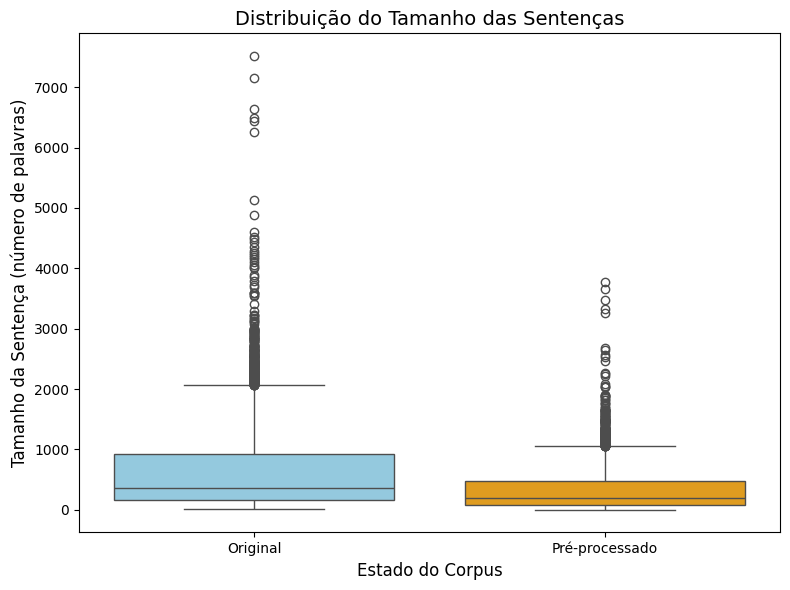

Redução média de tamanho no corpus: 47.3%


In [73]:
# Teste do template: boxplot de tamanho das sentenças no corpus real
if 'num_palavras_texto' not in df.columns:
    df['num_palavras_texto'] = df['texto_completo'].fillna('').astype(str).str.split().str.len()

if 'clean_text' not in df.columns:
    df['clean_text'] = df['texto_completo'].apply(text_cleaning)

df['num_palavras_limpo'] = df['clean_text'].fillna('').astype(str).str.split().str.len()

dados = pd.DataFrame({
    'Tamanho': df['num_palavras_texto'].tolist() + df['num_palavras_limpo'].tolist(),
    'Corpus': ['Original'] * len(df) + ['Pré-processado'] * len(df)
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Corpus', y='Tamanho', data=dados, palette=['skyblue', 'orange'])
plt.title('Distribuição do Tamanho das Sentenças', fontsize=14)
plt.xlabel('Estado do Corpus', fontsize=12)
plt.ylabel('Tamanho da Sentença (número de palavras)', fontsize=12)
plt.tight_layout()
plt.show()

reducao_media_pct = ((df['num_palavras_texto'] - df['num_palavras_limpo']) / df['num_palavras_texto'].replace(0, pd.NA)).mean() * 100
print(f'Redução média de tamanho no corpus: {reducao_media_pct:.1f}%')

## 5. Encerramento e Próxima Fase

A documentação deste notebook foi revisada para restabelecer o contexto metodológico e manter a coerência entre as etapas de preparação do corpus, EDA e pré-processamento.

### Entregáveis consolidados nesta fase
- ambiente Colab e Google Drive configurados;
- corpus consolidado com metadados e rótulos (`label=0` real, `label=1` fake);
- limpeza textual aplicada e comparações de tamanho antes/depois;
- base preparada para modelagem supervisionada.

### Checklist para início da próxima fase (modelagem)
- definir partições de treino, validação e teste com estratificação por classe;
- treinar baseline tradicional (ex.: TF-IDF + classificador linear);
- estabelecer métricas-alvo (F1, precisão, revocação e matriz de confusão);
- preparar pipeline Transformer para comparação justa com o baseline.

### Critério de passagem de fase
Prosseguir para modelagem somente após validar que as colunas usadas no treinamento (texto limpo e `label`) estão sem nulos e alinhadas ao mesmo conjunto de exemplos.